In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "studentmath"
dsetnamex = "Student-mat "
d = 30

#######
graphsx = np.load("../graphs/"+dsetname+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentmath_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-math (30),4.0,206,9,5,4,0.092233,0.063107,0.029126,2.111111,0.005063,0.004430,0.000633,10,5,190,1,0
1,Student-math (30),4.5,206,16,7,9,0.213592,0.111650,0.101942,2.750000,0.012368,0.006431,0.005937,14,13,174,0,1
2,Student-math (30),5.0,206,24,12,12,0.582524,0.368932,0.213592,5.000000,0.044684,0.028946,0.015738,25,19,145,0,2
3,Student-math (30),5.5,206,32,15,17,1.713592,0.966019,0.747573,11.031250,0.201349,0.116471,0.084878,24,34,97,0,3
4,Student-math (30),6.0,206,38,17,21,3.631068,2.038835,1.592233,19.684211,0.681773,0.404200,0.277573,21,27,61,0,4
5,Student-math (30),6.5,206,39,17,22,7.092233,3.902913,3.189320,37.461538,2.086657,1.221596,0.865060,8,22,33,0,5
6,Student-math (30),7.0,206,39,17,22,11.810680,6.233010,5.577670,62.384615,4.921344,2.769486,2.151857,8,23,9,0,6
7,Student-math (30),7.5,206,39,17,22,17.553398,8.956311,8.597087,92.717949,9.736879,5.188187,4.548693,2,12,3,0,7
8,Student-math (30),8.0,206,39,17,22,23.296117,11.572816,11.723301,123.051282,15.820649,8.202084,7.618565,0,8,1,0,8
9,Student-math (30),8.5,206,39,17,22,28.291262,13.674757,14.616505,149.435897,22.128439,11.164480,10.963959,1,3,0,0,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=True)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,r,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,studentmath (30),0,4.0,206,9,7.92,2.915000,144.0,62.0,...,1.54,132.62,57.38,100.000,93.30355,5.50004,4.70171,67.00000,16.50000,0.003761
1,2,studentmath (30),0,4.0,206,9,7.92,2.915000,144.0,62.0,...,1.54,132.62,57.38,100.000,93.30355,5.50004,4.70171,67.00000,16.50000,0.005740
2,3,studentmath (30),0,4.0,206,9,7.92,2.915000,144.0,62.0,...,1.54,132.62,57.38,100.000,93.30355,5.50004,4.70171,67.00000,16.50000,0.005991
3,4,studentmath (30),0,4.0,206,9,7.92,2.915000,144.0,62.0,...,1.54,132.62,57.38,100.000,93.30355,5.50004,4.70171,67.00000,16.50000,0.005819
4,5,studentmath (30),0,4.0,206,9,7.92,2.915000,144.0,62.0,...,1.54,132.62,57.38,100.000,93.30355,5.50004,4.70171,67.00000,16.50000,0.005555
5,1,studentmath (30),1,4.5,206,16,12.73,5.090000,144.0,62.0,...,4.02,121.68,52.32,95.518,90.17197,8.84030,8.20977,84.36104,43.58341,0.007300
6,2,studentmath (30),1,4.5,206,16,13.34,5.328333,144.0,62.0,...,4.02,121.68,52.32,100.000,94.48675,9.26391,8.59415,100.00000,59.55560,0.015385
7,3,studentmath (30),1,4.5,206,16,13.34,5.328333,144.0,62.0,...,4.02,121.68,52.32,100.000,94.48675,9.26391,8.59415,100.00000,59.55560,0.019152
8,4,studentmath (30),1,4.5,206,16,13.34,5.328333,144.0,62.0,...,4.02,121.68,52.32,100.000,94.48675,9.26391,8.59415,100.00000,59.55560,0.020516
9,5,studentmath (30),1,4.5,206,16,13.34,5.328333,144.0,62.0,...,4.02,121.68,52.32,100.000,94.48675,9.26391,8.59415,100.00000,59.55560,0.020551


## Plots

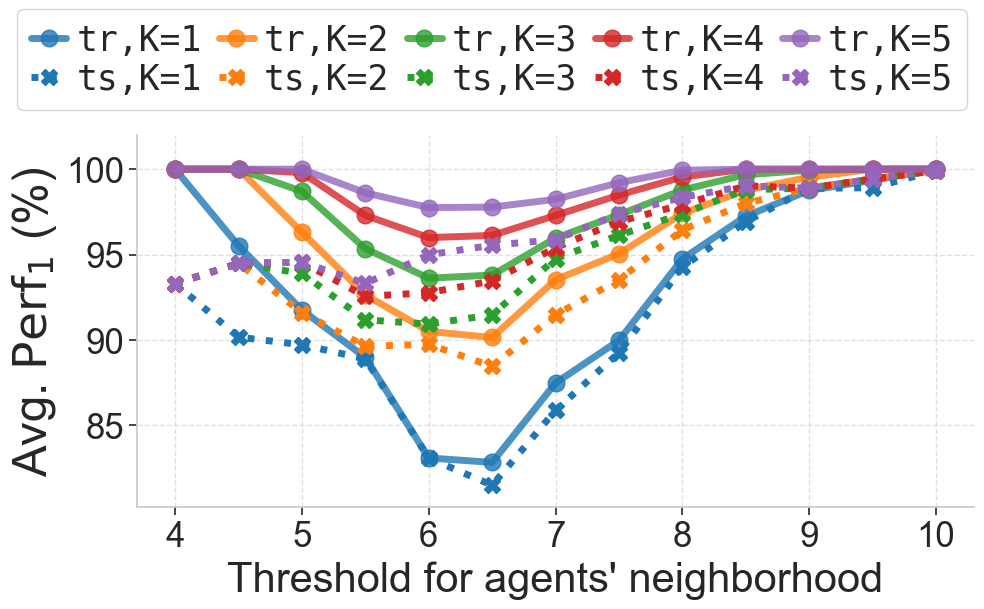

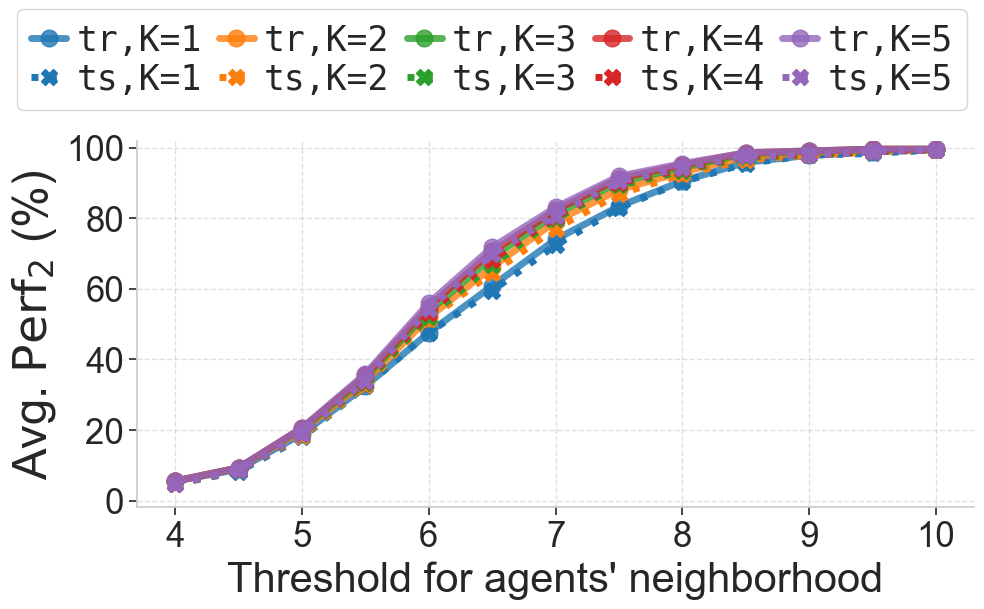

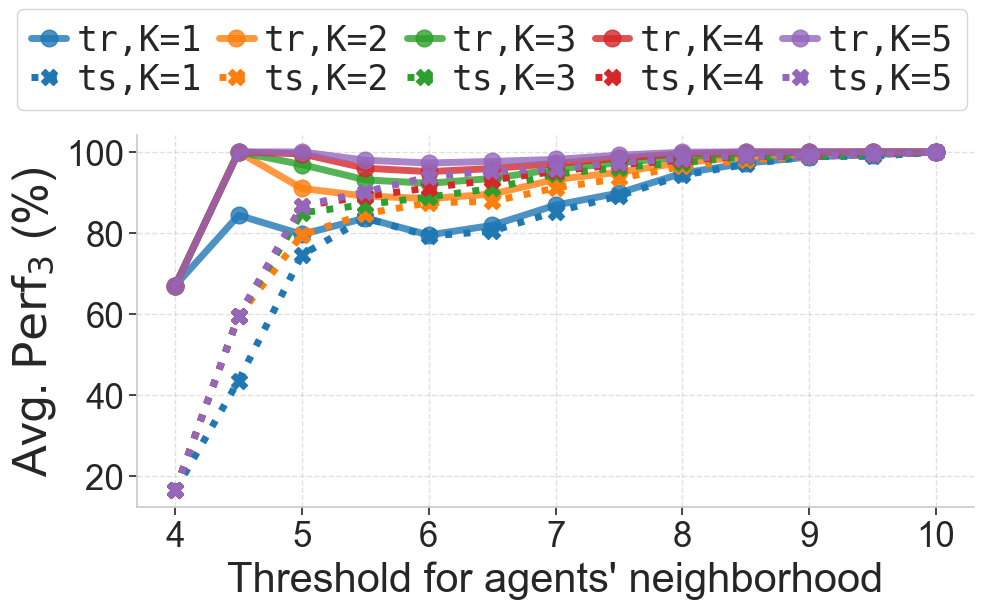

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf3.pdf")

